In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.options.mode.copy_on_write = True

In [2]:
def _load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    idx = pd.to_datetime(df.index, errors="coerce")
    df.index = idx.to_period("M").to_timestamp("M")
    df.index.name = "date"
    df = df.sort_index()

    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=1, how="all")

    return df.astype("float32")

DATA_FREQ = "M"

rets    = _load_df("sp500_returns_with_tickers.csv")
caps    = _load_df("sp500_market_caps.csv")
webc    = _load_df("ebc_weights.csv")
retsebc = _load_df("equal_beta_portfolio_return.csv")

print("Loaded:",
      "rets", rets.shape,
      "caps", caps.shape,
      "webc", webc.shape,
      "retsebc", retsebc.shape)

Loaded: rets (780, 1862) caps (780, 1863) webc (696, 1596) retsebc (696, 1)


In [3]:
# Align intersection of dates and tickers
common_index = rets.index.intersection(caps.index)
common_cols  = rets.columns.intersection(caps.columns)
rets = rets.loc[common_index, common_cols].sort_index()
caps = caps.loc[common_index, common_cols].sort_index()

print("After resample:", rets.shape, caps.shape)

After resample: (780, 1862) (780, 1862)


In [4]:
# Cap weights
cap_weights = caps.div(caps.sum(axis=1), axis=0).fillna(0.0)
ret_cap = (rets * cap_weights).sum(axis=1).astype("float32")
ret_cap.name = "ret_cap"

print("ret_cap:", ret_cap.shape, "nan%", ret_cap.isna().mean()*100)

ret_cap: (780,) nan% 0.0


In [5]:
# Equal Weights
n_active = caps.notna().sum(axis=1)
ew_weights = caps.notna().astype("float32").div(n_active, axis=0).fillna(0.0)

ret_eq = (rets * ew_weights).sum(axis=1).astype("float32")
ret_eq.name = "ret_eq"

print("ret_eq:", ret_eq.shape, "nan%", ret_eq.isna().mean()*100)

ret_eq: (780,) nan% 0.0


In [6]:
# EBC
ebc = retsebc.iloc[:, 0].rename("ebc")
print("ebc:", ebc.shape, "nan%", ret_eq.isna().mean()*100)

ebc: (696,) nan% 0.0


In [7]:
ports = pd.concat(
    [
        ret_cap.rename("cw"),
        (ret_cap - ebc).rename("cw-ebc"),
        (ret_cap - ret_eq).rename("cw-ew"),
    ],
    axis=1
).dropna()

print("Portfolio returns:", ports.shape, "|", ports.index.min(), "→", ports.index.max())
display(ports.head())

Portfolio returns: (696, 3) | 1967-01-31 00:00:00 → 2024-12-31 00:00:00


,cw,cw-ebc,cw-ew
date,,,
1967-01-31,0.083415,-0.022394,-0.040570
1967-02-28,0.010039,0.002736,0.001033
1967-03-31,0.044007,0.000430,-0.006551
1967-04-30,0.047458,0.014722,0.009782
1967-05-31,-0.044615,-0.016680,-0.016120


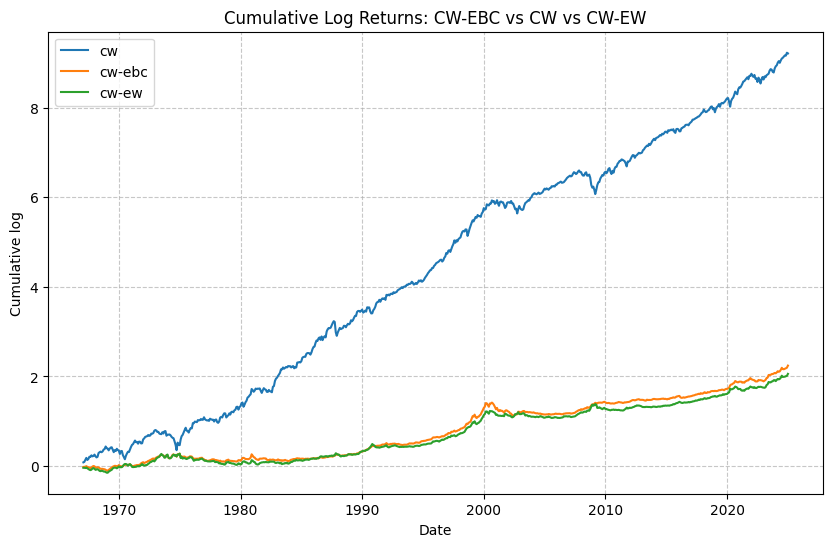

In [8]:
import numpy as np
import matplotlib.pyplot as plt

df = ports[["cw", "cw-ebc", "cw-ew"]].dropna().sort_index()
cum = np.log1p(df).cumsum()

plt.figure(figsize=(10,6))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.title("Cumulative Log Returns: CW-EBC vs CW vs CW-EW")
plt.xlabel("Date")
plt.ylabel("Cumulative log")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [9]:
ff5 = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")
ff5.set_index("Date", inplace=True)
ff5 = ff5.astype(float) / 100

ffm = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")
ffm.set_index("Date", inplace=True)
ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [10]:
ff_p = ff.copy()
ff_p.index = ff_p.index.to_period("M")  

pref = ports[["cw", "cw-ew", "cw-ebc"]].copy()
pref_p = pref.copy()
pref_p.index = pref_p.index.to_period("M")

idx_p = pref_p.index.intersection(ff_p.index)
pref_p = pref_p.loc[idx_p].astype(float)
ff_p   = ff_p.loc[idx_p].astype(float)

print("Aligned (PeriodIndex) span:", idx_p.min(), "→", idx_p.max(), "| rows:", len(idx_p))

pref_m = pref_p.copy()
ff_m   = ff_p.copy()
pref_m.index = pref_m.index.to_timestamp(how="end")
ff_m.index   = ff_m.index.to_timestamp(how="end")

Aligned (PeriodIndex) span: 1967-01 → 2024-12 | rows: 696


In [11]:
df_aligned = pd.concat(
    [
        pref_m[["cw-ebc", "cw-ew"]],
        ff_m[["SMB", "HML", "RMW", "CMA", "Mom"]],
    ],
    axis=1,
).dropna()

desc = df_aligned[["cw-ebc", "cw-ew"]].describe().T[["mean", "std", "min", "max"]]
desc["Sharpe_annual"] = desc["mean"] / desc["std"] * np.sqrt(12)
display(desc)

print("Corrs:")
corrs = df_aligned.corr().loc[
    ["cw-ebc", "cw-ew"], [ "SMB", "HML", "RMW", "CMA", "Mom"]
]
display(corrs)

,mean,std,min,max,Sharpe_annual
cw-ebc,0.003357,0.016295,-0.081846,0.082725,0.713730
cw-ew,0.003105,0.017098,-0.092538,0.083511,0.629033


Corrs:


,SMB,HML,RMW,CMA,Mom
cw-ebc,-0.377486,-0.537371,-0.090618,-0.419124,0.260377
cw-ew,-0.604760,-0.381247,0.108766,-0.185168,0.435792


In [12]:
import statsmodels.api as sm

X = sm.add_constant(df_aligned[[ "SMB", "HML", "RMW", "CMA", "Mom"]])
for fac in ["cw-ebc", "cw-ew"]:
    y = df_aligned[fac]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    print("="*24, fac, "="*24)
    print(m.summary())
    print("Annualized alpha:", float(m.params["const"]) * 12, "\n")

======================== cw-ebc ========================
                            OLS Regression Results                            
Dep. Variable:                 cw-ebc   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     50.84
Date:                Sun, 28 Sep 2025   Prob (F-statistic):           6.93e-45
Time:                        14:45:01   Log-Likelihood:                 2125.4
No. Observations:                 696   AIC:                            -4239.
Df Residuals:                     690   BIC:                            -4211.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

## Normal Fama Mcb

In [13]:
def nw_mean_t(series: pd.Series, lags: int = 6):
    y = pd.to_numeric(pd.Series(series), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(y) == 0:
        return np.nan, np.nan, np.nan
    y_arr = y.to_numpy(dtype="float64")
    X_arr = np.ones((len(y_arr), 1), dtype="float64")
    res = sm.OLS(y_arr, X_arr).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    mean = float(res.params[0]); se = float(res.bse[0])
    tval = mean / se if se > 0 else np.nan
    return mean, se, tval


def rolling_beta_single_factor(returns_df: pd.DataFrame, factor: pd.Series, window: int = 36) -> pd.DataFrame:
    R = returns_df.astype("float32"); f = factor.astype("float32")
    mean_R = R.rolling(window, min_periods=window).mean()
    mean_f = f.rolling(window, min_periods=window).mean()
    EXY    = (R.mul(f, axis=0)).rolling(window, min_periods=window).mean()
    covRf  = EXY - mean_R.mul(mean_f, axis=0)
    Ef2    = (f.pow(2)).rolling(window, min_periods=window).mean()
    var_f  = Ef2 - mean_f.pow(2)
    return covRf.div(var_f, axis=0)

def fama_macbeth(rets: pd.DataFrame,
                 pref_series: pd.Series,
                 mkt_series: pd.Series | None = None,
                 window: int = 36,
                 nw_lags: int = 6,
                 min_stocks: int = 50,
                 verbose: bool = True):

    idx = rets.index
    if mkt_series is not None:
        idx = idx.intersection(mkt_series.index)
    idx = idx.intersection(pref_series.index)
    R      = rets.loc[idx].astype("float64")
    f_pref = pref_series.loc[idx].astype("float64")
    f_mkt  = mkt_series.loc[idx].astype("float64") if mkt_series is not None else None

    beta_pref = rolling_beta_single_factor(R, f_pref, window=window).shift(1)
    beta_mkt  = rolling_beta_single_factor(R, f_mkt,  window=window).shift(1) if f_mkt is not None else None

    valid_mask = beta_pref.notna().any(axis=1)
    dates_all  = beta_pref.index[valid_mask].to_list()
    if len(dates_all) < 2:
        raise ValueError("No usable data.")

    lambdas, lambdas_mkt, r2_cs, Ns = [], [], [], []
    kept_months = skipped_smallN = skipped_allNaN = 0

    for i in range(len(dates_all) - 1):
        t  = dates_all[i]
        t1 = dates_all[i + 1]

        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        if beta_mkt is not None:
            X["beta_mkt"] = beta_mkt.loc[t]
        y_next = R.loc[t1]  

        df = X.join(y_next.rename("ret_next")).replace([np.inf, -np.inf], np.nan).dropna()
        if df.empty:
            skipped_allNaN += 1; continue
        if len(df) < min_stocks:
            skipped_smallN += 1; continue

        feats = ["beta_pref"] + (["beta_mkt"] if beta_mkt is not None else [])
        X_arr = sm.add_constant(df[feats].astype("float64").to_numpy())
        y_arr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(y_arr, X_arr).fit()

        lambdas.append(mdl.params[1])                
        if beta_mkt is not None:
            lambdas_mkt.append(mdl.params[2])         
        r2_cs.append(mdl.rsquared); Ns.append(len(df))
        kept_months += 1

    if verbose:
        print(f"[FM] kept months={kept_months}, skipped_smallN={skipped_smallN}, skipped_allNaN={skipped_allNaN}")

    out = {}
    if kept_months == 0:
        out["lambda_pref_mean"] = out["lambda_pref_t"] = out["mean_crosssec_R2"] = out["mean_N"] = np.nan
        return out

    lam_s = pd.Series(lambdas, index=[d for d in dates_all[1:1+len(lambdas)]])
    mean_lam, se_lam, t_lam = nw_mean_t(lam_s, lags=nw_lags)
    out["lambda_pref_mean"] = mean_lam
    out["lambda_pref_t"]    = t_lam
    out["lambda_pref_se"]   = se_lam

    if mkt_series is not None and len(lambdas_mkt) > 0:
        lam_mkt_s = pd.Series(lambdas_mkt, index=lam_s.index[:len(lambdas_mkt)])
        mean_lm, se_lm, t_lmkt = nw_mean_t(lam_mkt_s, lags=nw_lags)
        out["lambda_mkt_mean"] = mean_lm
        out["lambda_mkt_t"]    = t_lmkt
        out["lambda_mkt_se"]   = se_lm

    out["mean_crosssec_R2"] = float(np.nanmean(r2_cs)) if r2_cs else np.nan
    out["mean_N"]           = float(np.nanmean(Ns))    if Ns else np.nan
    out["lambda_series"]    = lam_s
    return out

In [14]:
rets    = rets.copy()
pref_m  = pref_m.copy()

rets.index   = pd.PeriodIndex(pd.to_datetime(rets.index),   freq="M").to_timestamp("M")
pref_m.index = pd.PeriodIndex(pd.to_datetime(pref_m.index), freq="M").to_timestamp("M")

rets.sort_index(inplace=True);      pref_m.sort_index(inplace=True)
rets = rets[~rets.index.duplicated()];  pref_m = pref_m[~pref_m.index.duplicated()]

idx = rets.index.intersection(pref_m.index)
print("len idx:", len(idx), "|", idx.min(), "→", idx.max())

len idx: 696 | 1967-01-31 00:00:00 → 2024-12-31 00:00:00


In [15]:
for pref_name in ["cw-ebc", "cw-ew"]:
    fm_out = fama_macbeth(rets=rets,
                          pref_series=pref_m[pref_name],
                          mkt_series=None,
                          window=36, nw_lags=6,
                          min_stocks=50, verbose=False)
    print(f"[FM] {pref_name}  mean λ={fm_out.get('lambda_pref_mean')},  t={fm_out.get('lambda_pref_t')},  "
          f"mean CS R²={fm_out.get('mean_crosssec_R2')},  mean N={fm_out.get('mean_N')}")

[FM] cw-ebc  mean λ=-0.0007419535162990249,  t=-1.4521398268511303,  mean CS R²=0.032532809242909785,  mean N=431.27769347496206
[FM] cw-ew  mean λ=-0.0007896080484487559,  t=-1.5160640566751897,  mean CS R²=0.043753334298865375,  mean N=431.27769347496206


In [16]:
ff_m = ff_m.copy()
ff_m.index = pd.PeriodIndex(pd.to_datetime(ff_m.index, errors="coerce"), freq="M").to_timestamp("M")
ff_m.sort_index(inplace=True)

In [17]:
fac_names = ["SMB","HML","RMW","CMA","Mom"]
beta_ctrl = {}
for nm in fac_names:
    beta_ctrl[nm] = rolling_beta_single_factor(rets, ff_m[nm], window=36).shift(1)

def fama_macbeth_with_controls(rets, beta_pref, beta_ctrl_dict, min_stocks=50, nw_lags=6):
    dates = beta_pref.index[beta_pref.notna().any(axis=1)].to_list()
    lam_pref, lam_ctrl, Ns, R2 = [], {k: [] for k in beta_ctrl_dict}, [], []
    import statsmodels.api as sm
    for i in range(len(dates)-1):
        t, t1 = dates[i], dates[i+1]
        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        for k, B in beta_ctrl_dict.items():
            X[k] = B.loc[t]
        y = rets.loc[t1]  
        df = X.join(y.rename("ret_next")).replace([np.inf,-np.inf], np.nan).dropna()
        if len(df) < min_stocks: continue
        cols = ["beta_pref"] + fac_names
        Xarr = sm.add_constant(df[cols].astype("float64").to_numpy())
        yarr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(yarr, Xarr).fit()
        lam_pref.append(mdl.params[1])
        for j,k in enumerate(fac_names, start=2):
            lam_ctrl[k].append(mdl.params[j])
        R2.append(mdl.rsquared); Ns.append(len(df))
    
    def nw(s):
        y = pd.Series(s).dropna()
        if len(y)==0: return np.nan, np.nan
        res = sm.OLS(y, np.ones((len(y),1))).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
        return float(res.params[0]), float(res.tvalues[0])
    out = {"lambda_pref": nw(lam_pref), "mean_R2": float(np.nanmean(R2)), "mean_N": float(np.nanmean(Ns))}
    out["lambda_ctrl"] = {k: nw(v) for k,v in lam_ctrl.items()}
    return out

beta_pref = rolling_beta_single_factor(rets, pref_m["cw-ebc"], window=36).shift(1)
res_ctrl = fama_macbeth_with_controls(rets, beta_pref, beta_ctrl)
print("λ_pref mean,t =", res_ctrl["lambda_pref"])
print(" mean R²:", res_ctrl["mean_R2"])
print(" | mean N:", res_ctrl["mean_N"])
print("controls (mean,t):", res_ctrl["lambda_ctrl"])

λ_pref mean,t = (-0.001519984025540824, -1.887792525057274)
 mean R²: 0.10674297424487512
 | mean N: 431.27769347496206
controls (mean,t): {'SMB': (-0.0011846833442370535, -0.9149169674881753), 'HML': (0.00015815836313405515, 0.10856032283716513), 'RMW': (0.0003416096306112255, 0.30399352447759465), 'CMA': (-0.00034210622599168945, -0.42285064013099394), 'Mom': (0.0018152518807868188, 1.3455411712322891)}


C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

In [18]:
W = 36         
min_stocks = 50
nw_lags = 6
pref_list = ["cw-ebc", "cw-ew"]          
fac_names = ["SMB","HML","RMW","CMA","Mom"]  

beta_ctrl = {
    nm: rolling_beta_single_factor(rets, ff_m[nm], window=W).shift(1)
    for nm in fac_names
}
rows = []
for pref_name in pref_list:
    beta_pref = rolling_beta_single_factor(rets, pref_m[pref_name], window=W).shift(1)
    res = fama_macbeth_with_controls(
        rets=rets,
        beta_pref=beta_pref,
        beta_ctrl_dict=beta_ctrl,
        min_stocks=min_stocks,
        nw_lags=nw_lags
    )
    row = {
        "factor": pref_name,
        "lambda_pref_mean": res["lambda_pref"][0],
        "t_lambda_pref":    res["lambda_pref"][1],
        "mean_R2":          res["mean_R2"],
        "mean_N":           res["mean_N"],
    }
   
    for k, (m, t) in res["lambda_ctrl"].items():
        row[f"{k}_mean"] = m
        row[f"{k}_t"]    = t
    rows.append(row)

res_table = pd.DataFrame(rows)

order_cols = (
    ["factor","lambda_pref_mean","t_lambda_pref","mean_R2","mean_N"] +
    sum([[f"{k}_mean", f"{k}_t"] for k in fac_names], [])
)
res_table = res_table[order_cols]

display(res_table)

C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_49876\1849781980.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

,factor,lambda_pref_mean,t_lambda_pref,mean_R2,mean_N,SMB_mean,SMB_t,HML_mean,HML_t,RMW_mean,RMW_t,CMA_mean,CMA_t,Mom_mean,Mom_t
0,cw-ebc,-0.001520,-1.887793,0.106743,431.277693,-0.001185,-0.914917,0.000158,0.108560,0.000342,0.303994,-0.000342,-0.422851,0.001815,1.345541
1,cw-ew,-0.000962,-0.999530,0.107002,431.277693,-0.000416,-0.351119,0.000329,0.217728,0.000425,0.382345,-0.000263,-0.329952,0.001821,1.290467


In [19]:
print("CW-EBC:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["cw-ebc"], None, window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")

print("CW-EW:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["cw-ew"], None, window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")

CW-EBC:
W=24: λ=-0.0006601631984983043, t=-1.5639133189331764
W=36: λ=-0.0007419535162990249, t=-1.4521398268511303
W=60: λ=-0.001157431549278643, t=-1.9497385341457698
CW-EW:
W=24: λ=-0.0006572544453700694, t=-1.4621176592399459
W=36: λ=-0.0007896080484487559, t=-1.5160640566751897
W=60: λ=-0.0010044758337873904, t=-1.743742192763186


In [20]:
ports_p = ports.copy()
ff_p    = ff.copy()
ports_p.index = pd.PeriodIndex(pd.to_datetime(ports_p.index), freq="M")
ff_p.index    = pd.PeriodIndex(pd.to_datetime(ff_p.index),    freq="M")

need_factors = ["SMB", "HML", "RMW", "CMA", "Mom"]
missing = [c for c in need_factors if c not in ff_p.columns]
if missing:
    raise ValueError(f"Factors missing in ff: {missing}")

idx_p = ports_p.index.intersection(ff_p.index)

panel = pd.concat(
    [ports_p.loc[idx_p, ["cw", "cw-ebc", "cw-ew"]].astype("float32"),
     ff_p.loc[idx_p, need_factors].astype("float32")],
    axis=1
).dropna()

print("Panel:", panel.shape, "|", panel.index.min(), "→", panel.index.max())
panel.head()

Panel: (696, 8) | 1967-01 → 2024-12


,cw,cw-ebc,cw-ew,SMB,HML,RMW,CMA,Mom
1967-01,0.083415,-0.022394,-0.040570,0.0898,0.0236,0.0129,-0.0306,-0.0700
1967-02,0.010039,0.002736,0.001033,0.0301,-0.0226,0.0166,-0.0093,0.0351
1967-03,0.044007,0.000430,-0.006551,0.0177,0.0047,0.0082,-0.0150,0.0139
1967-04,0.047458,0.014722,0.009782,0.0043,-0.0229,0.0309,-0.0372,0.0052
1967-05,-0.044615,-0.016680,-0.016120,0.0245,0.0080,-0.0119,0.0162,0.0066


In [21]:
# -------- Cell N: FF6 regressions (OLS + HAC) and tidy outputs --------
import numpy as np
import statsmodels.api as sm
import os

def ff6_reg(df, yname, maxlags=6):
    y_ex = df[yname]
    X = sm.add_constant(df[["SMB","HML","RMW","CMA","Mom"]])
    model = sm.OLS(y_ex, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
    return model

def pack_row(name, model):
    p, t = model.params, model.tvalues
    alpha_m = p["const"]
    alpha_ann = (1.0 + alpha_m)**12 - 1.0
    return {
        "strategy": name,
        "alpha_ann_%": alpha_ann * 100.0,
        "t_alpha(NW)": t["const"],
        "beta_SMB": p["SMB"],   "t_SMB": t["SMB"],
        "beta_HML": p["HML"],   "t_HML": t["HML"],
        "beta_RMW": p["RMW"],   "t_RMW": t["RMW"],
        "beta_CMA": p["CMA"],   "t_CMA": t["CMA"],
        "beta_Mom": p["Mom"],   "t_Mom": t["Mom"],
        "R2": model.rsquared, "Obs": int(model.nobs)
    }

def print_summary_no_datetime(title, model):
    txt = model.summary().as_text()
    lines = []
    for ln in txt.splitlines():
        if ln.strip().startswith("Date:") or ln.strip().startswith("Time:"):
            continue
        lines.append(ln)
    print("="*86)
    print(title)
    print("="*86)
    print("\n".join(lines))
    print()

res_ew  = ff6_reg(panel, "cw-ew",  maxlags=6)
res_ebc = ff6_reg(panel, "cw-ebc", maxlags=6)

print_summary_no_datetime("FF6 Regression: CW − EW",  res_ew)
print_summary_no_datetime("FF6 Regression: CW − EBC", res_ebc)

summary_df = pd.DataFrame([pack_row("CW−EW", res_ew),
                           pack_row("CW−EBC", res_ebc)]).set_index("strategy")
display(summary_df.round(3))

summary_path = os.path.join("cache", "ff6_summary_cw_ew_ebc.parquet")
summary_df.to_parquet(summary_path)
print("Saved:", summary_path)


FF6 Regression: CW − EW
                            OLS Regression Results                            
Dep. Variable:                  cw-ew   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     119.3
No. Observations:                 696   AIC:                            -4337.
Df Residuals:                     690   BIC:                            -4310.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.000      8.096      0.000       0.003       0.005
SMB           -0.3418      0.028    -12.250      0.000      -0.396      -0.287
HML           -0.1524      0

,alpha_ann_%,t_alpha(NW),beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,beta_Mom,t_Mom,R2,Obs
strategy,,,,,,,,,,,,,,
CW−EW,4.570,8.096,-0.342,-12.250,-0.152,-5.030,-0.087,-1.634,-0.037,-1.040,0.131,5.337,0.612,696
CW−EBC,6.037,9.295,-0.246,-9.162,-0.169,-5.306,-0.173,-3.262,-0.185,-5.095,0.065,2.317,0.508,696


Saved: cache\ff6_summary_cw_ew_ebc.parquet


In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def run_bfm_rolling_fast_monthend(
    rets: pd.DataFrame,
    ff:   pd.DataFrame,
    pref_series: pd.Series,
    window: int = 60,
    ridge:  None | float | str = "auto",   
    orthogonalize: bool = False,
):

    need = ["SMB","HML","RMW","CMA","Mom","RF"]
    missing = [c for c in need if c not in ff.columns]
    if missing:
        raise ValueError(f"ff : {missing}")

    to_mend = lambda idx: pd.PeriodIndex(pd.to_datetime(idx, errors="coerce"), freq="M").to_timestamp("M")
    idx = to_mend(rets.index).intersection(to_mend(ff.index)).intersection(to_mend(pref_series.index))

    R  = rets.copy(); R.index = to_mend(R.index);  R = R.loc[idx].astype("float64")
    F6 = ff.loc[:, ["SMB","HML","RMW","CMA","Mom"]].copy()
    F6.index = to_mend(F6.index); F6 = F6.loc[idx].astype("float64")
    RF = ff["RF"].copy(); RF.index = to_mend(RF.index); RF = RF.loc[idx].astype("float64")
    pref = pd.to_numeric(pref_series.copy(), errors="coerce"); pref.index = to_mend(pref.index); pref = pref.loc[idx].astype("float64")

    if orthogonalize:
        Xb  = sm.add_constant(F6.values)
        fit = sm.OLS(pref.values, Xb).fit()
        pref = pd.Series(pref.values - fit.predict(Xb), index=pref.index)

    F_all = pd.concat([F6, pref.rename("Pref")], axis=1)
    X_all = sm.add_constant(F_all.values)        # (T × 7)
    RX    = R.sub(RF, axis=0).values             # (T × N)

    k = 6
    T, N = RX.shape
    dates, lambdas = [], []

    for t in range(window, T):
        rows = slice(t - window, t)
        Xw, Yw = X_all[rows, :], RX[rows, :]     # (W×7), (W×N)

        # Stage-1：β
        XtX = Xw.T @ Xw
        XtY = Xw.T @ Yw
        B_all = np.linalg.pinv(XtX) @ XtY        # (7×N)
        B = B_all[1:, :].T                       # (N×6)

        # Stage-2： OLS / Ridge
        y_t  = RX[t, :]
        mask = np.isfinite(y_t) & np.all(np.isfinite(B), axis=1)
        if mask.sum() < k + 5:
            continue
        M, y = B[mask, :], y_t[mask]             # (m×6), (m,)

        if ridge is None:
            # FMB
            lam, *_ = np.linalg.lstsq(M, y, rcond=None)  # (6,)
        else:
            # Ridge（Bayesian FMB）
            std = M.std(axis=0, ddof=0); std[std==0] = 1.0
            Z   = M / std
            BtB = Z.T @ Z
            BtY = Z.T @ y
            if ridge == "auto":
                alpha = 0.1 * (np.trace(BtB) / k)        
            else:
                alpha = float(ridge)
            lam = np.linalg.solve(BtB + alpha*np.eye(k), BtY) / std

        lambdas.append(lam); dates.append(idx[t])

    colsX = ["SMB","HML","RMW","CMA","Mom","Pref"]
    Lambda = pd.DataFrame(lambdas, index=dates, columns=colsX)

    # Newey–West t for mean λ
    rows = []
    for c in Lambda.columns:
        s = Lambda[c].dropna()
        if len(s) < 12:
            rows.append({"factor": c, "lambda_mean_month": np.nan, "lambda_mean_annual": np.nan, "t_NW": np.nan})
            continue
        res = sm.OLS(s.values, np.ones((len(s),1))).fit(cov_type="HAC", cov_kwds={"maxlags": max(1, len(s)//12)})
        rows.append({"factor": c,
                     "lambda_mean_month": float(res.params[0]),
                     "lambda_mean_annual": float(res.params[0])*12,
                     "t_NW": float(res.tvalues[0])})
    summary = pd.DataFrame(rows).set_index("factor").sort_index()
    return summary, Lambda

In [23]:
def _to_mend(idx):
    return pd.PeriodIndex(pd.to_datetime(idx, errors="coerce"), freq="M").to_timestamp("M")

rets_ = rets.copy(); rets_.index = _to_mend(rets_.index); rets_.sort_index(inplace=True)
ff__  = ff_.copy() if 'ff_' in globals() else ff.copy()
ff__.index = _to_mend(ff__.index); ff__.sort_index(inplace=True)

ret_cap_ = ret_cap.copy();  ret_cap_.index = _to_mend(ret_cap_.index);  ret_cap_.sort_index(inplace=True)
ret_eq_  = ret_eq.copy();   ret_eq_.index  = _to_mend(ret_eq_.index);   ret_eq_.sort_index(inplace=True)
prefret_ = ports.copy(); prefret_.index = _to_mend(prefret_.index); prefret_.sort_index(inplace=True)

cw_ew  = ports["cw-ew"].copy()
cw_ebc = ports["cw-ebc"].copy()

assert all(c in ff__.columns for c in ["SMB","HML","RMW","CMA","Mom","RF"]) 
print("rets_ :", rets_.index.min(), "→", rets_.index.max(), "| N stocks:", rets_.shape[1])
print("ff__  :", ff__.index.min(),  "→", ff__.index.max())
print("cw-ew :", cw_ew.index.min(),  "→", cw_ew.index.max(),  "| NaN%:", cw_ew.isna().mean().round(3))
print("cw-ebc:", cw_ebc.index.min(), "→", cw_ebc.index.max(), "| NaN%:", cw_ebc.isna().mean().round(3))


rets_ : 1960-01-31 00:00:00 → 2024-12-31 00:00:00 | N stocks: 1862
ff__  : 1963-07-31 00:00:00 → 2025-04-30 00:00:00
cw-ew : 1967-01-31 00:00:00 → 2024-12-31 00:00:00 | NaN%: 0.0
cw-ebc: 1967-01-31 00:00:00 → 2024-12-31 00:00:00 | NaN%: 0.0


In [24]:
import matplotlib.pyplot as plt

_DEFAULT_ORDER = ["SMB","HML","RMW","CMA","Mom","Pref"]

# ---------- Main ----------
def plot_bfm_all(summary: pd.DataFrame, Lambda: pd.DataFrame, title="FF6 + Pref"):
    if "lambda_mean_annual" not in summary.columns or "t_NW" not in summary.columns:
        raise KeyError("summary must contain ['lambda_mean_annual','t_NW'].")

    cols = [c for c in _DEFAULT_ORDER if c in summary.index]  # summary 是按行索引
    s_ann = summary["lambda_mean_annual"].reindex(cols).dropna()
    s_t   = summary["t_NW"].reindex(cols).dropna()

    Lcols = [c for c in _DEFAULT_ORDER if c in Lambda.columns]
    L     = Lambda.reindex(columns=Lcols).dropna(how="all")

    fig = plt.figure(figsize=(12, 8))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1,1.4])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, :])

    # Annualized risk price
    ax1.bar(s_ann.index, s_ann.values)
    ax1.set_title(f"{title} — Annualized Risk Prices (λ̄×12)")
    ax1.axhline(0, color="gray", lw=1)

    # NW t-stat
    ax2.bar(s_t.index, s_t.values)
    ax2.set_title(f"{title} — Newey–West t-stat")
    for y,c,ls in [(0,"gray","-"),(1.96,"red","--"),(2.58,"orange",":"),(-1.96,"red","--"),(-2.58,"orange",":")]:
        ax2.axhline(y, color=c, ls=ls, lw=1)

    # λ_t timeseries
    for c in ["Pref","SMB","HML","CMA","Mom"]:
        if c in L.columns:
            ax3.plot(L.index, L[c], label=f"{c} (monthly λ)")
            ax3.plot(L.index, L[c].rolling(12).mean(), "--", label=f"{c} (12m avg)")
    ax3.axhline(0, color="gray", lw=1)
    ax3.set_title(f"{title} — Monthly λ_t")
    ax3.legend(ncol=2, fontsize=9)

    fig.tight_layout()
    plt.show()

# ---------- rolling NW t(mean) ----------
def rolling_nw_t_of_mean(series: pd.Series, window: int = 60, maxlags: int = 6, min_frac: float = 0.8) -> pd.Series:
    s = series.copy()
    out = pd.Series(index=s.index, dtype=float)
    for i in range(window - 1, len(s)):
        win = s.iloc[i - window + 1: i + 1].dropna()
        if len(win) < max(int(window * min_frac), 12):
            out.iloc[i] = np.nan
            continue
        X = np.ones((len(win), 1))
        res = sm.OLS(win.values, X).fit(cov_type="HAC", cov_kwds={"maxlags": min(maxlags, max(1, len(win)//4))})
        out.iloc[i] = float(res.tvalues[0])
    return out

# ---------- λ  + rolling t ----------
def plot_lambda_and_t_series(Lambda: pd.DataFrame, factor: str = "Pref", roll_win: int = 60, nw_maxlags: int = 6, title: str = ""):
    if factor not in Lambda.columns:
        raise KeyError(f"{factor} not in Lambda columns: {list(Lambda.columns)}")

    lam = Lambda[factor].copy()
    t_rolling = rolling_nw_t_of_mean(lam, window=roll_win, maxlags=nw_maxlags)

    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(lam.index, lam.values, label=f"{factor} (monthly λ)")
    ax[0].plot(lam.index, lam.rolling(12).mean(), "--", label=f"{factor} (12m avg)")
    ax[0].axhline(0, color="gray", lw=1)
    ax[0].set_title(f"{title} — {factor} λ_t")
    ax[0].legend(loc="upper left")

    ax[1].plot(t_rolling.index, t_rolling.values, label=f"Rolling NW t-stat (win={roll_win})")
    for y,c,ls in [(0,"gray","-"),(1.96,"red","--"),(2.58,"orange",":"),(-1.96,"red","--"),(-2.58,"orange",":")]:
        ax[1].axhline(y, color=c, ls=ls, lw=1)
    ax[1].set_title(f"{title} — Rolling t-stat of mean(λ)")
    ax[1].legend(loc="upper left")
    fig.tight_layout(); plt.show()

# ---------- CW−EW vs CW−EBC ----------
def plot_pref_compare(Lambda_ew: pd.DataFrame, Lambda_ebc: pd.DataFrame, win: int, title: str = "Pref λ Comparison"):
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    ax[0].plot(Lambda_ew.index,  Lambda_ew["Pref"], label=f"CW−EW (λ_t)")
    ax[0].plot(Lambda_ew.index,  Lambda_ew["Pref"].rolling(12).mean(), "--", label="CW−EW (12m avg)")
    ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"], label=f"CW−EBC (λ_t)")
    ax[0].plot(Lambda_ebc.index, Lambda_ebc["Pref"].rolling(12).mean(), "--", label="CW−EBC (12m avg)")
    ax[0].axhline(0, color="gray", lw=1); ax[0].legend(ncol=2); ax[0].set_title(f"{title} | Win={win}")

    t_ew  = rolling_nw_t_of_mean(Lambda_ew["Pref"],  window=win, maxlags=6)
    t_ebc = rolling_nw_t_of_mean(Lambda_ebc["Pref"], window=win, maxlags=6)
    ax[1].plot(t_ew.index,  t_ew,  label="CW−EW  rolling t")
    ax[1].plot(t_ebc.index, t_ebc, label="CW−EBC rolling t")
    for y,c,ls in [(0,"gray","-"), (1.96,"red","--"), (2.58,"orange",":"), (-1.96,"red","--"), (-2.58,"orange",":")]:
        ax[1].axhline(y, color=c, ls=ls, lw=1)
    ax[1].legend(ncol=2); ax[1].set_title("Rolling NW t-stat of mean(λ)")
    fig.tight_layout(); plt.show()

# ---------- λ_t ----------
def plot_all_factors_timeseries(Lambda: pd.DataFrame, title: str = "Monthly λ_t (all factors)"):
    cols = [c for c in _DEFAULT_ORDER if c in Lambda.columns]
    r, c = 3, 3
    fig, axes = plt.subplots(r, c, figsize=(14, 9), sharex=True)
    axes = axes.ravel()
    for i, name in enumerate(cols):
        ax = axes[i]
        ax.plot(Lambda.index, Lambda[name], label=f"{name} (λ_t)")
        ax.plot(Lambda.index, Lambda[name].rolling(12).mean(), "--", label="12m avg")
        ax.axhline(0, color="gray", lw=1)
        ax.set_title(name); ax.legend(fontsize=8)
    for j in range(len(cols), r*c):
        fig.delaxes(axes[j])
    fig.suptitle(title); fig.tight_layout(rect=[0,0,1,0.97]); plt.show()

# ---------- λ heat ----------
def plot_lambda_corr_heatmap(Lambda: pd.DataFrame, title: str = "Corr of λ (factors)"):
    cols = [c for c in _DEFAULT_ORDER if c in Lambda.columns]
    C = Lambda[cols].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    ax.set_xticks(range(len(cols))); ax.set_yticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=45, ha="right"); ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f"{C.iloc[i,j]:.2f}", ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.85); ax.set_title(title); fig.tight_layout(); plt.show()


=== Rolling BFM — CW−EW | Win=36 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0007,-0.0082,-1.3770
HML,-0.0001,-0.0016,-0.2042
Mom,-0.0009,-0.0103,-0.8947
Pref,-0.0013,-0.0152,-3.2724
RMW,-0.0003,-0.0035,-0.6788
SMB,0.0005,0.0058,0.7527


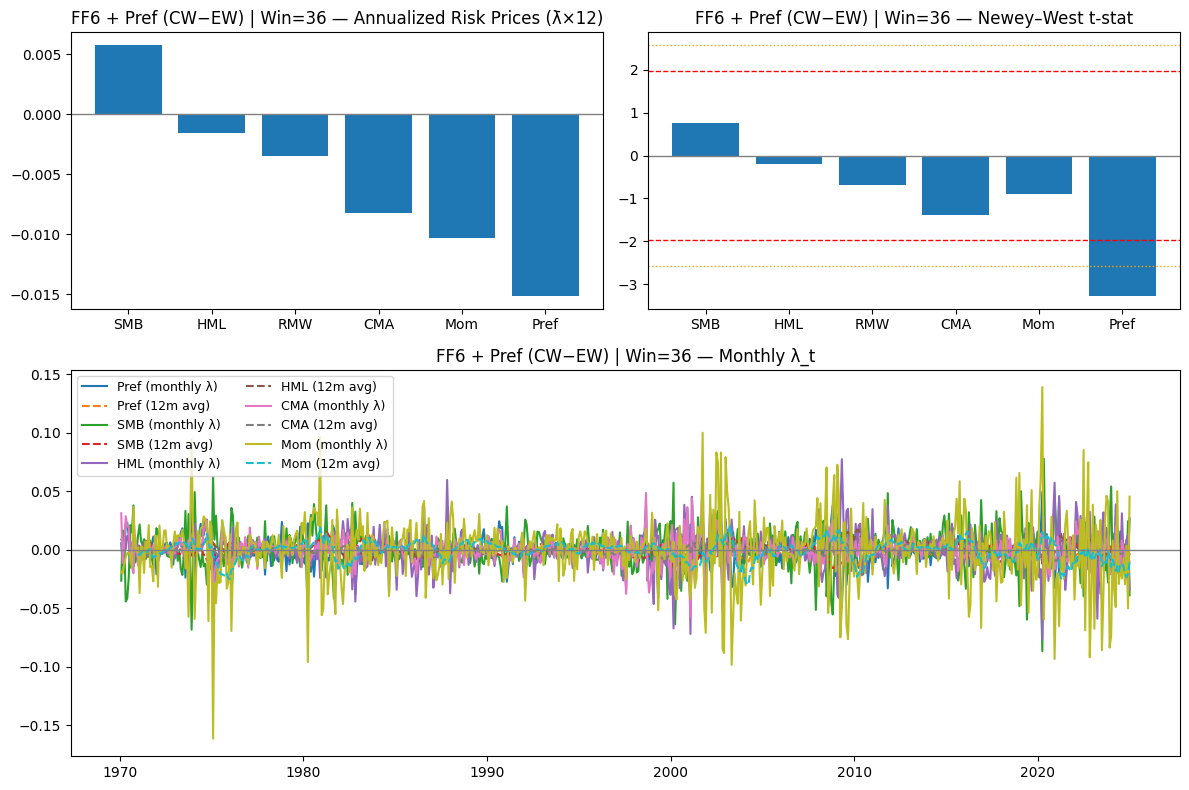

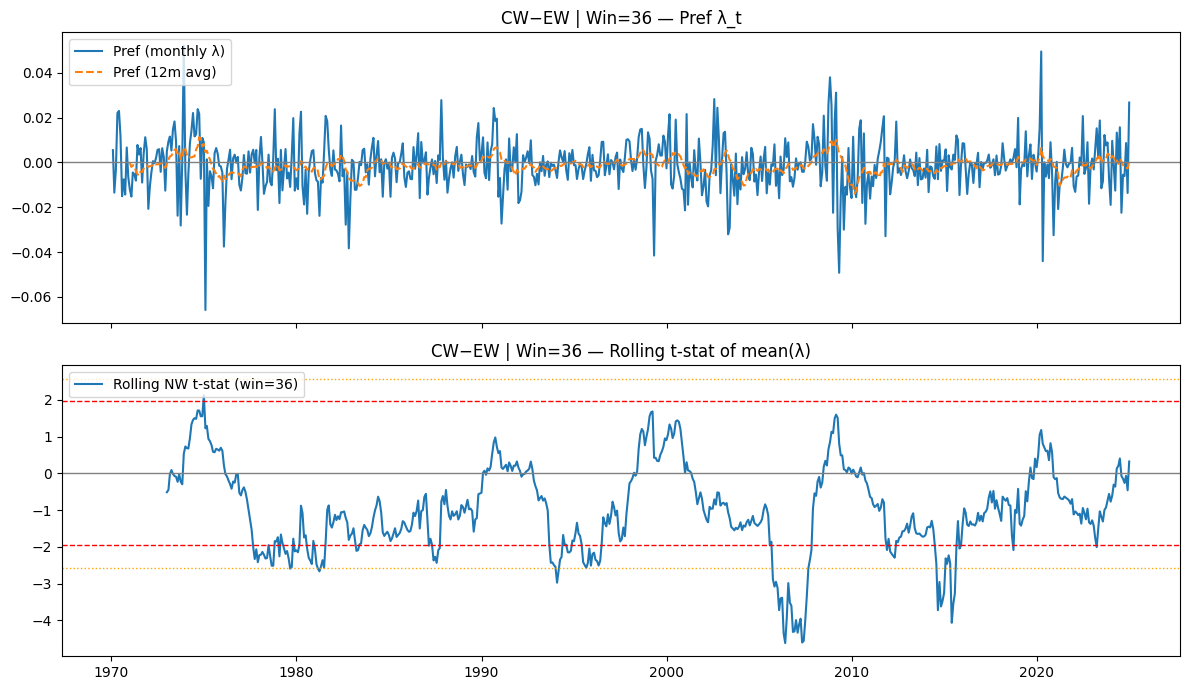


=== Rolling BFM — CW−EBC | Win=36 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0008,-0.0095,-1.6717
HML,-0.0001,-0.0015,-0.1917
Mom,-0.0010,-0.0123,-1.1122
Pref,-0.0007,-0.0089,-1.8037
RMW,-0.0004,-0.0042,-0.8021
SMB,0.0009,0.0102,1.1917


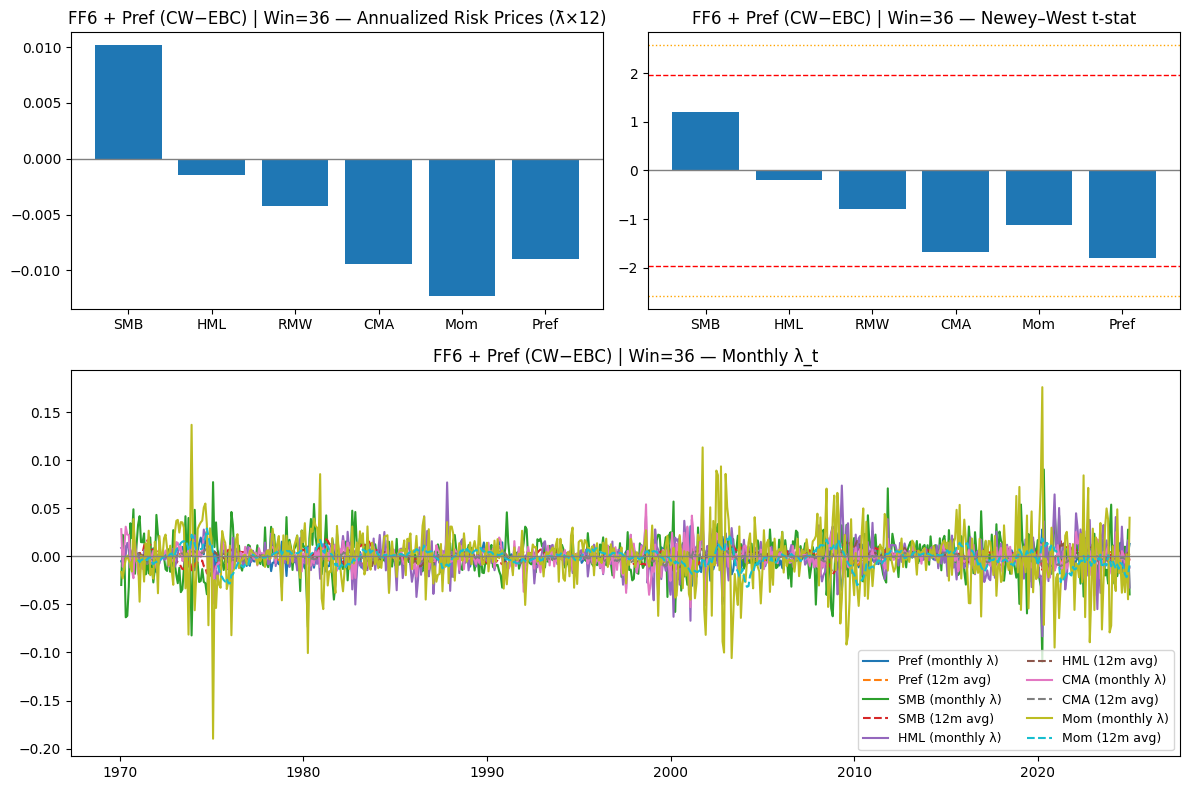

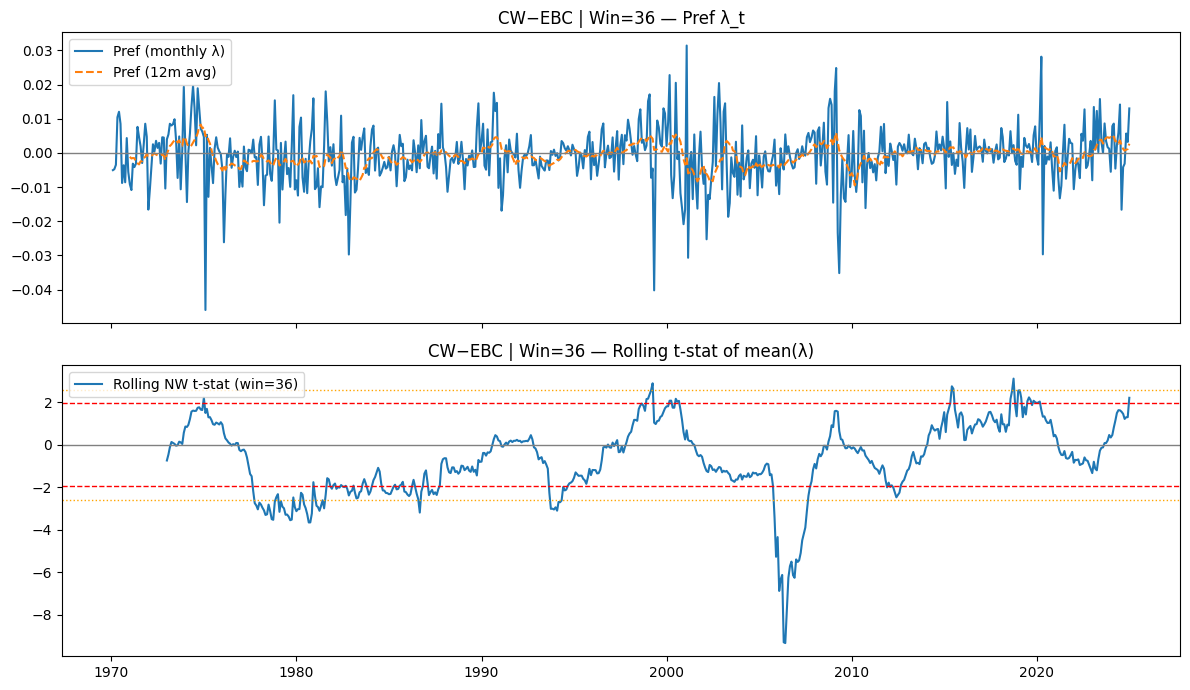

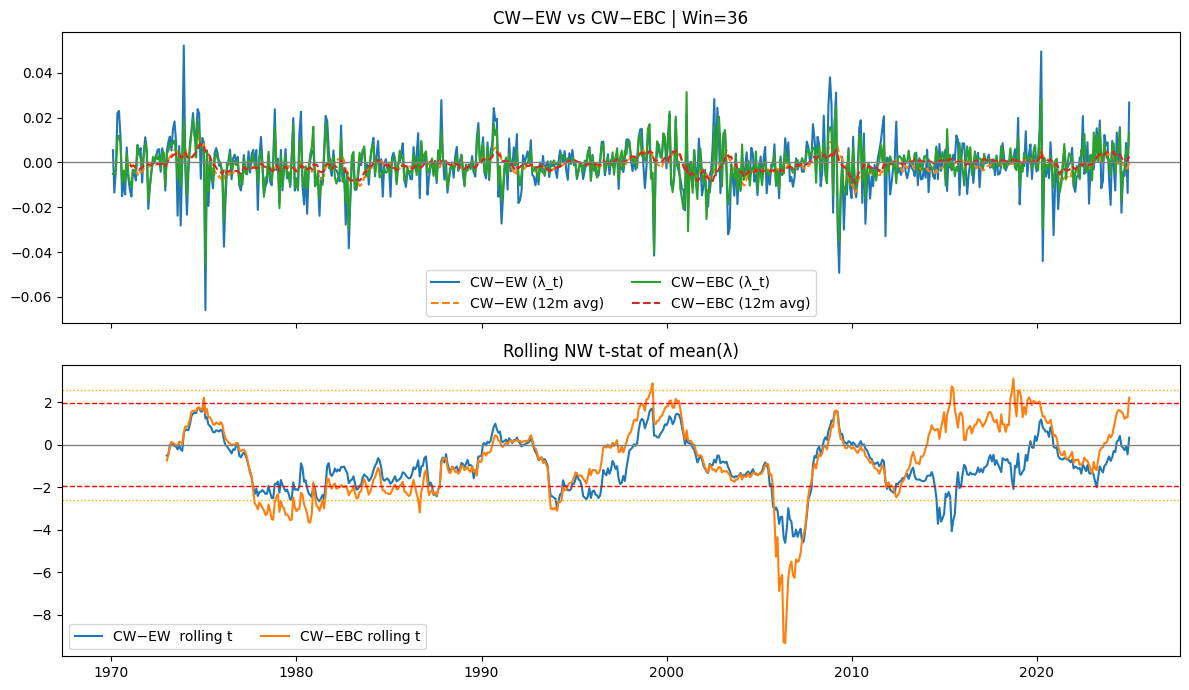

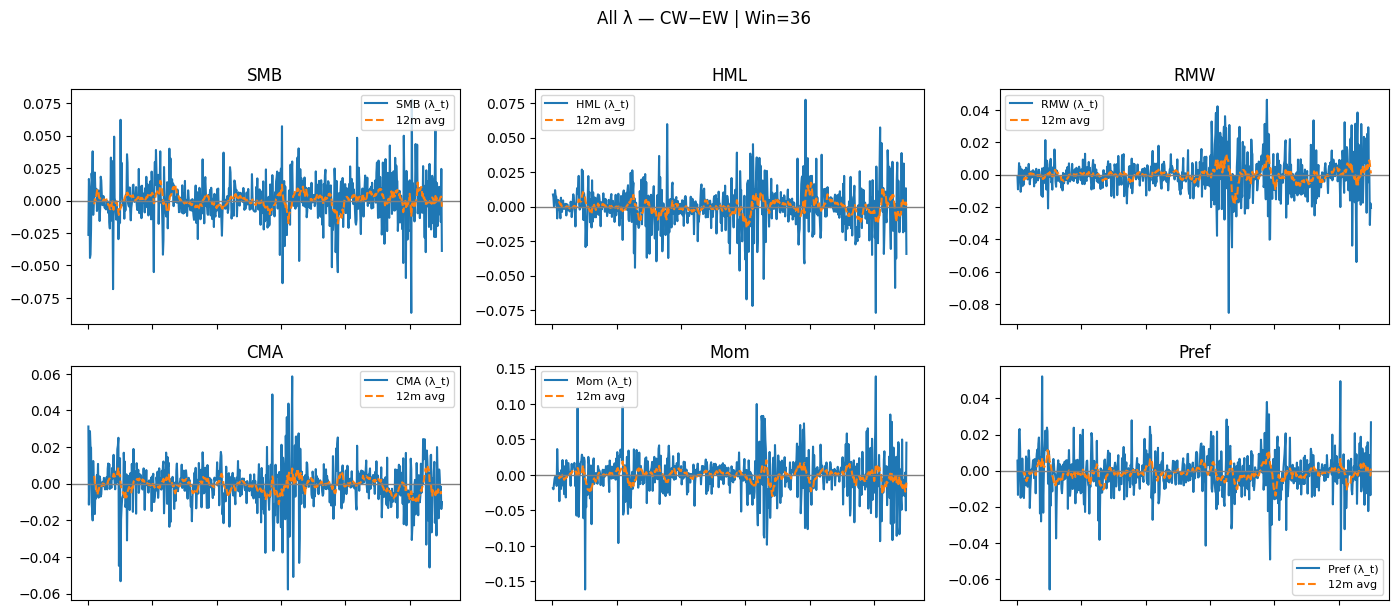

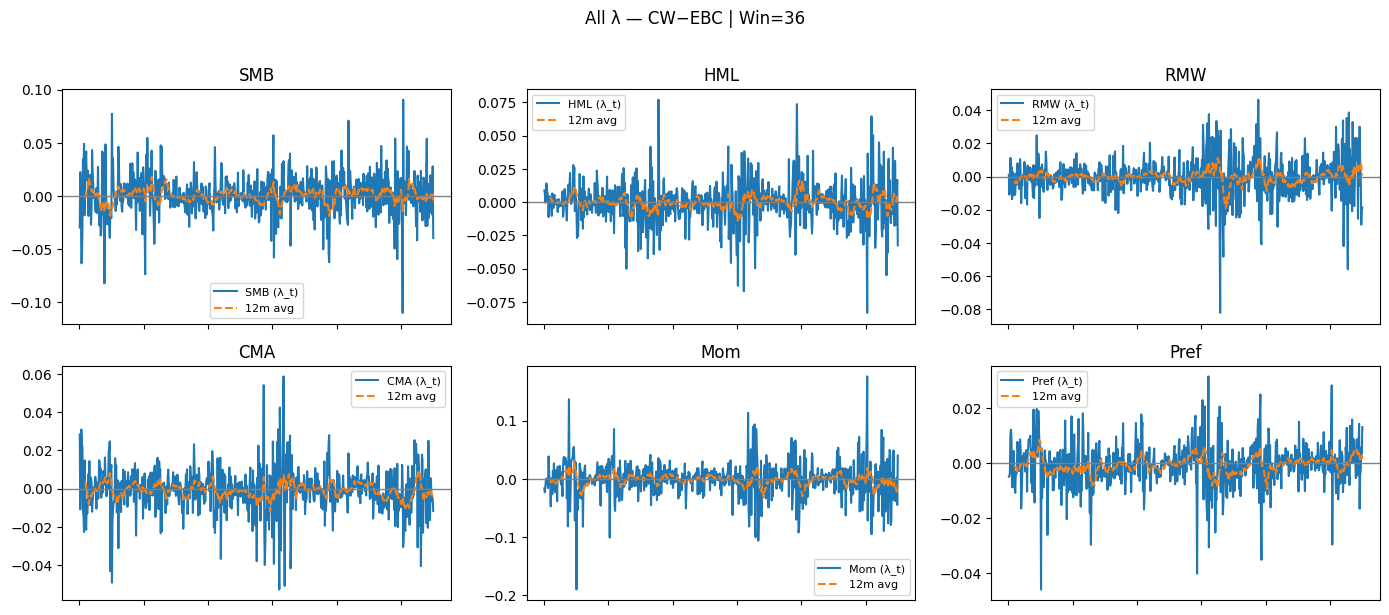

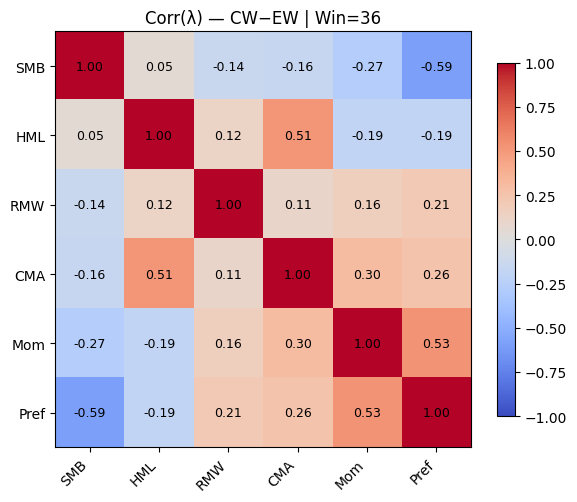

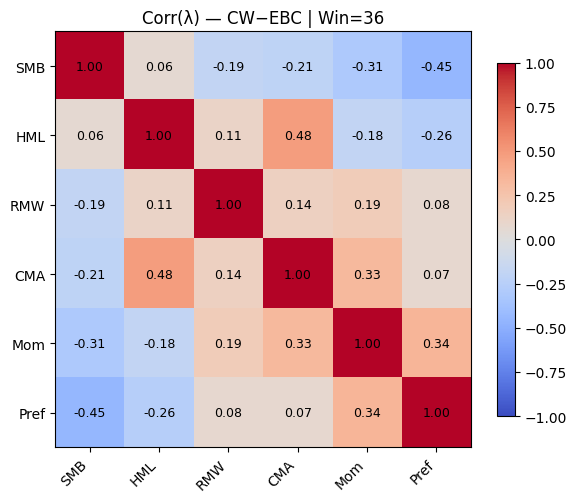


=== Rolling BFM — CW−EW | Win=60 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0010,-0.0116,-1.6707
HML,-0.0001,-0.0014,-0.1840
Mom,-0.0005,-0.0062,-0.4329
Pref,-0.0017,-0.0200,-4.0131
RMW,-0.0002,-0.0028,-0.4076
SMB,0.0010,0.0115,1.1898


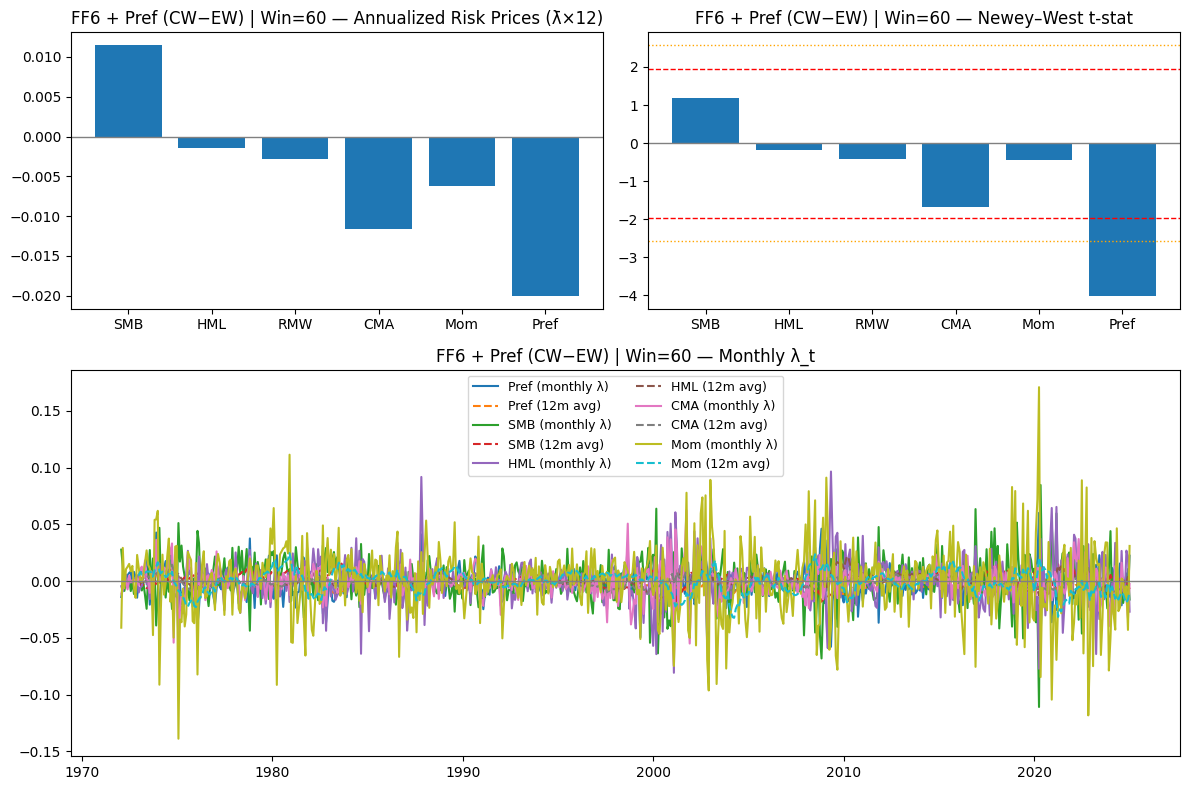

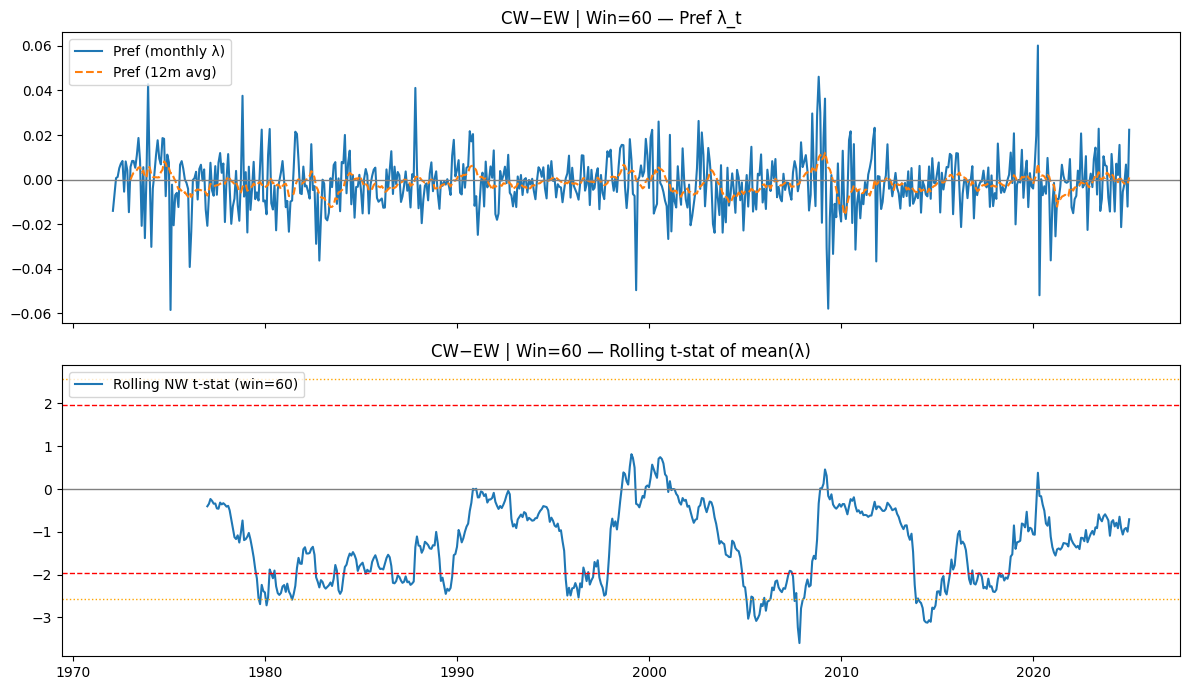


=== Rolling BFM — CW−EBC | Win=60 ===


,lambda_mean_month,lambda_mean_annual,t_NW
factor,,,
CMA,-0.0011,-0.0134,-1.8636
HML,-0.0002,-0.0027,-0.3492
Mom,-0.0011,-0.0131,-0.8619
Pref,-0.0011,-0.0132,-2.4910
RMW,-0.0004,-0.0047,-0.6999
SMB,0.0013,0.0159,1.5786


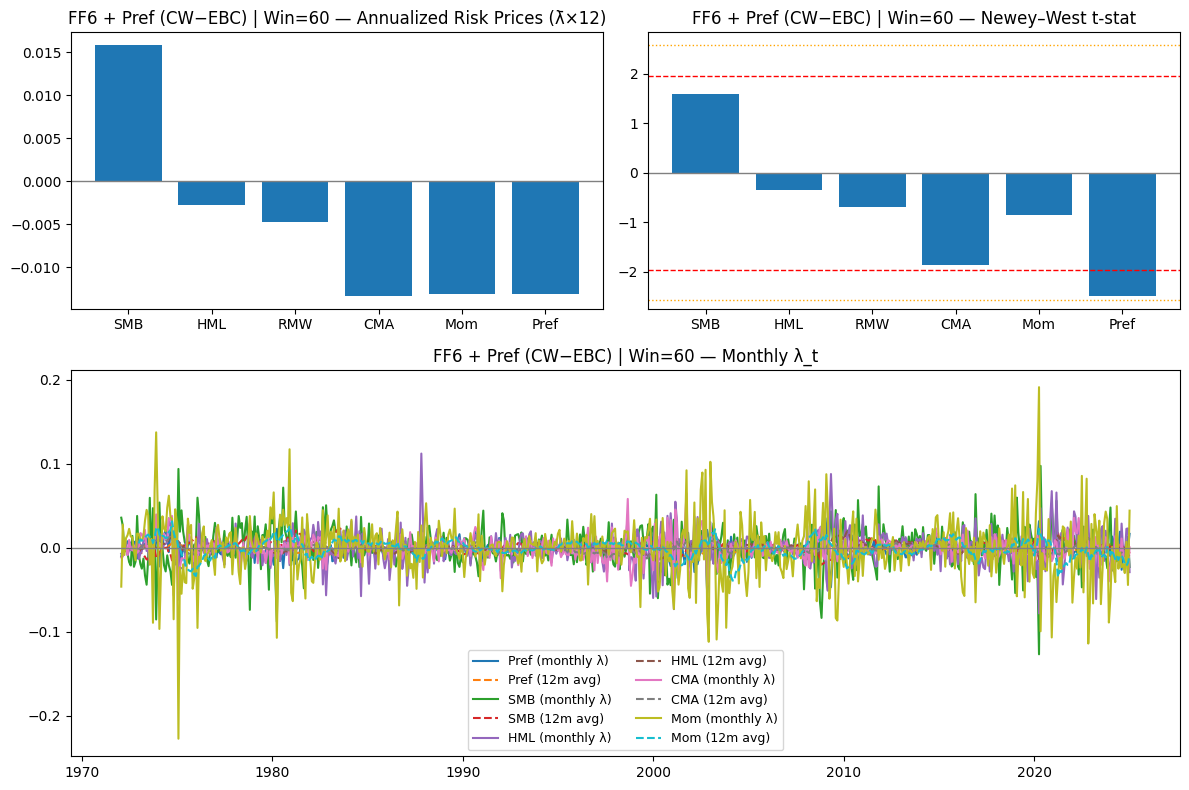

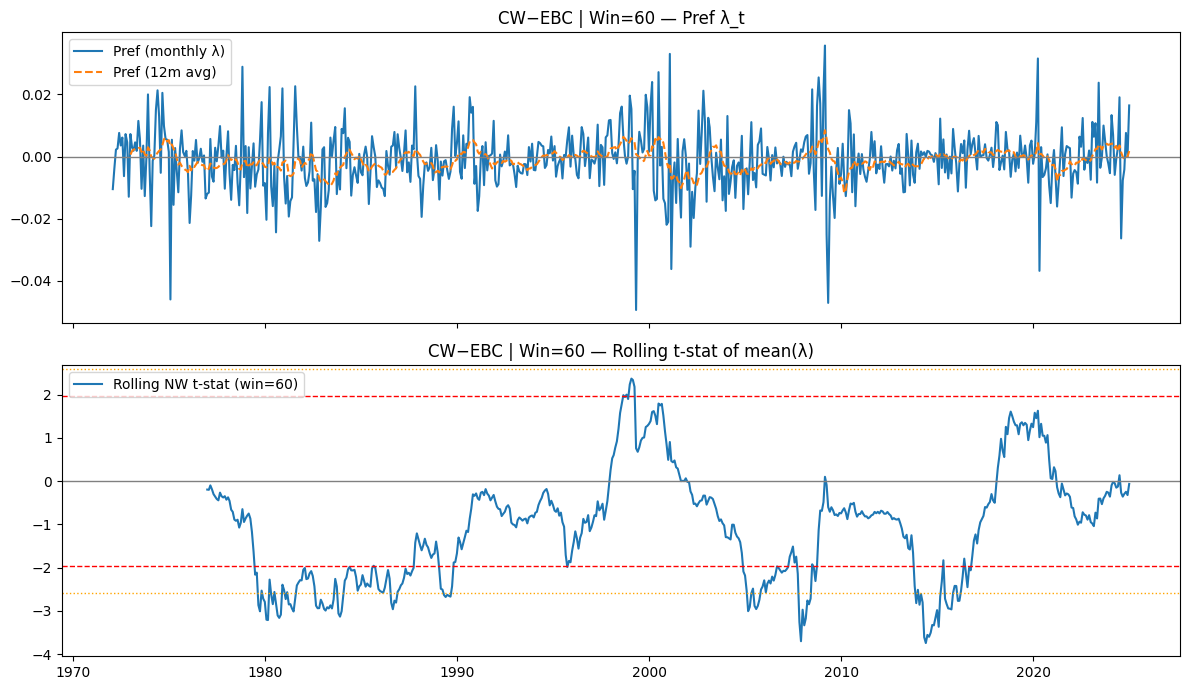

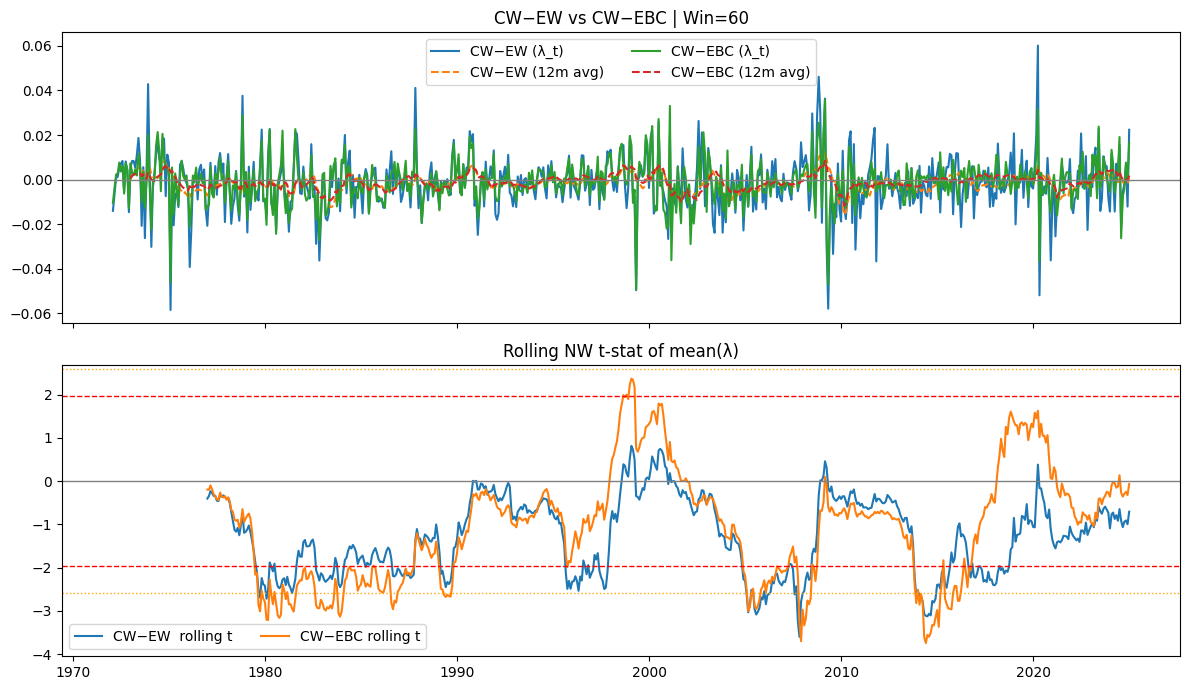

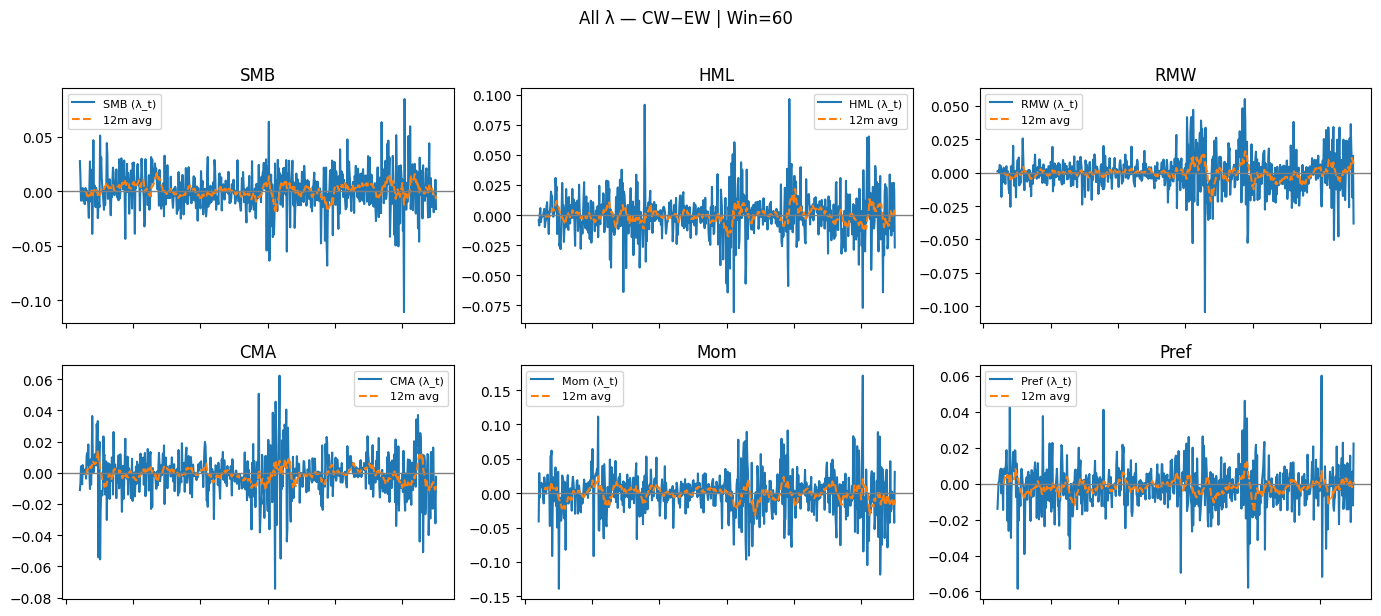

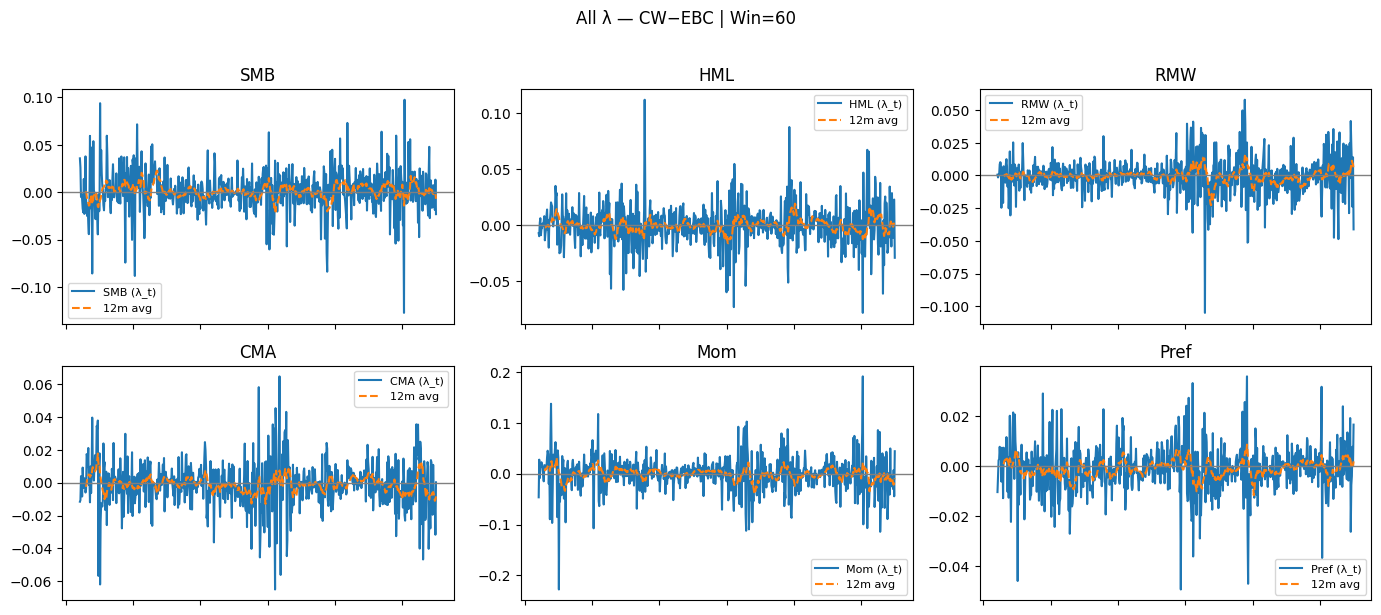

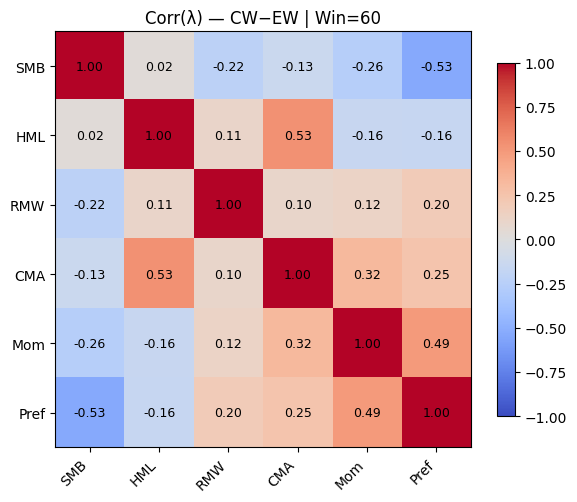

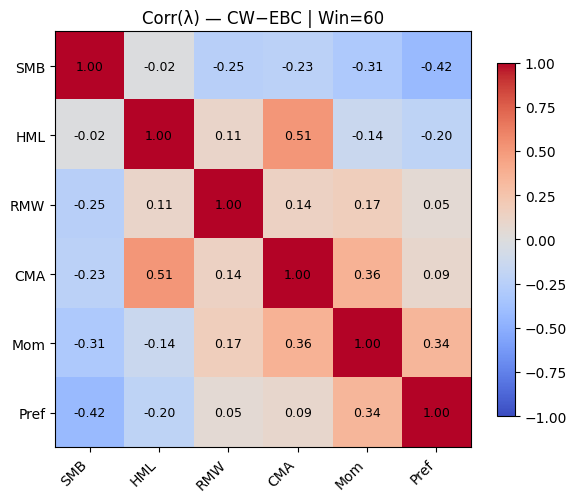


=== Pref risk price comparison across windows (rolling) ===


,lambda_mean_month,lambda_mean_annual,t_NW
CW−EW | 36m,-0.0013,-0.0152,-3.2724
CW−EBC | 36m,-0.0007,-0.0089,-1.8037
CW−EW | 60m,-0.0017,-0.0200,-4.0131
CW−EBC | 60m,-0.0011,-0.0132,-2.4910


In [27]:
WINDOWS = [36, 60]
USE_RIDGE   = True
RIDGE_ALPHA = None      
NW_MAXLAGS  = 6
ORTHO_PREF  = False     

all_pref_rows = []

for WIN in WINDOWS:
    _ridge = (None if not USE_RIDGE else ("auto" if RIDGE_ALPHA is None else float(RIDGE_ALPHA)))

    sum_ew, Lambda_ew = run_bfm_rolling_fast_monthend(
        rets=rets_, ff=ff__, pref_series=cw_ew,
        window=WIN, ridge=_ridge,
        orthogonalize=ORTHO_PREF
    )

    print(f"\n=== Rolling BFM — CW−EW | Win={WIN} ===")
    display(sum_ew.round(4))
    
    plot_bfm_all(sum_ew, Lambda_ew, title=f"FF6 + Pref (CW−EW) | Win={WIN}")
    plot_lambda_and_t_series(Lambda_ew, factor="Pref", roll_win=WIN,
                             nw_maxlags=NW_MAXLAGS, title=f"CW−EW | Win={WIN}")

    # ---- CW−EBC  ----
    sum_ebc, Lambda_ebc = run_bfm_rolling_fast_monthend(
        rets=rets_, ff=ff__, pref_series=cw_ebc,
        window=WIN, ridge=_ridge,
        orthogonalize=ORTHO_PREF
    )
    print(f"\n=== Rolling BFM — CW−EBC | Win={WIN} ===")
    display(sum_ebc.round(4))
    plot_bfm_all(sum_ebc, Lambda_ebc, title=f"FF6 + Pref (CW−EBC) | Win={WIN}")
    plot_lambda_and_t_series(Lambda_ebc, factor="Pref", roll_win=WIN,
                             nw_maxlags=NW_MAXLAGS, title=f"CW−EBC | Win={WIN}")

    plot_pref_compare(Lambda_ew, Lambda_ebc, win=WIN, title="CW−EW vs CW−EBC")
    plot_all_factors_timeseries(Lambda_ew,  title=f"All λ — CW−EW | Win={WIN}")
    plot_all_factors_timeseries(Lambda_ebc, title=f"All λ — CW−EBC | Win={WIN}")
    plot_lambda_corr_heatmap(Lambda_ew,  title=f"Corr(λ) — CW−EW | Win={WIN}")
    plot_lambda_corr_heatmap(Lambda_ebc, title=f"Corr(λ) — CW−EBC | Win={WIN}")

    pref_row_ew  = sum_ew.loc["Pref"].rename(f"CW−EW | {WIN}m")
    pref_row_ebc = sum_ebc.loc["Pref"].rename(f"CW−EBC | {WIN}m")
    all_pref_rows.extend([pref_row_ew, pref_row_ebc])

compare_pref = pd.DataFrame(all_pref_rows)[["lambda_mean_month", "lambda_mean_annual", "t_NW"]]
print("\n=== Pref risk price comparison across windows (rolling) ===")
display(compare_pref.round(4))